머신러닝: K-Means <br>
신규기업, 외부유입 인구, 프랜차이즈 증가율, 상권활력도

In [38]:
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [39]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"

df = pd.read_csv(DATA_DIR / "행정동_분기_마스터(최종).csv", encoding="utf-8-sig")

### (1) 신규기업 증가율

1. 증가율 계산

In [40]:
df_yoy = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
             "base_quarter", "new_corp_cnt"]].copy()

# 동/연/분기 기준으로 정렬
df_yoy = df_yoy.sort_values(["adm_dong_cd", "year", "quarter"])

# (YoY 계산용) 동일한 분기끼리 1년 전 값 가져오기
df_yoy["new_corp_cnt_prev"] = (
    df_yoy.groupby(["adm_dong_cd", "quarter"])["new_corp_cnt"].shift(1)
)

# YoY 증가율 (%) — 분모 0/NaN 처리
df_yoy["new_corp_yoy"] = (
    (df_yoy["new_corp_cnt"] - df_yoy["new_corp_cnt_prev"])
    / df_yoy["new_corp_cnt_prev"]
) * 100

2. 전처리

In [41]:
# 2022년 대비 2023년 동 분기 증가율 확인 불가(NaN) 
# K-Means는 데이터 양/분포에 민감한 모델
# 중앙값으로 채울 경우 문제: YoY는 "변화율"이라 분포가 큼: "데이터 부재"로 인한 결측치인데 존재하지 않는 변화율을 만들어 평균적인 성장처럼 보이게 함(해석 왜곡)
# 데이터 보존 위해 값을 0("성장 없음")으로 채우되 yoy_missing으로 결측 여부 정보 추가 
df_yoy["yoy_missing"] = (
    df_yoy["new_corp_cnt_prev"].isna() |
    (df_yoy["new_corp_cnt_prev"] == 0)
).astype(int)

In [42]:
df_yoy["new_corp_yoy"] = df_yoy["new_corp_yoy"].replace([np.inf, -np.inf], np.nan)
#np.inf는 양의 무한대, -np.inf는 음의 무한대
#모델이 이해할 수 없는 무한대는 NaN로 처리

df_yoy["new_corp_yoy"] = df_yoy["new_corp_yoy"].fillna(0)

In [43]:
# 성능 개선(군집 분류 ↑) 위해 YoY(장기 변화) + QoQ(단기 변화)
df_yoy["new_corp_qoq"] = (
    df_yoy.groupby("adm_dong_cd")["new_corp_cnt"]
    .pct_change() * 100
) # pct_change(): 바로 이전 값 대비

df_yoy["qoq_missing"] = df_yoy["new_corp_qoq"].isnull().astype(int)
df_yoy["new_corp_qoq"] = df_yoy["new_corp_qoq"].replace([np.inf, -np.inf], np.nan)
df_yoy["new_corp_qoq"] = df_yoy["new_corp_qoq"].fillna(0)

In [44]:
# count 기반 feature: lookback 확보를 위해 2023 데이터까지 사용해 계산한 뒤 2024+로 필터
df_yoy = df_yoy.sort_values(["adm_dong_cd", "year", "quarter"])
g_cnt = df_yoy.groupby("adm_dong_cd")["new_corp_cnt"]

# (a) 최근 4분기 평균 = 절대 수준(scale) 정보
df_yoy["cnt_roll4_mean"] = g_cnt.transform(
    lambda s: s.rolling(4, min_periods=2).mean()
)

# (b) 최근 4분기 변화량 = 현재값 - 4분기 전 값 (YoY와 같은 시점이지만 % 아닌 절대량)
df_yoy["cnt_diff4"] = g_cnt.transform(lambda s: s - s.shift(4))

In [45]:
# K-Means 입력용: 2023년은 YoY 계산 불가(2022 데이터 없음) → 군집 입력에서 제외
df_yoy_input = df_yoy[df_yoy["year"] != 2023].copy()
df_yoy_input[["cnt_roll4_mean", "cnt_diff4"]] = (
    df_yoy_input[["cnt_roll4_mean", "cnt_diff4"]].fillna(0)
)

# 결측 품질 점검은 따로 보관 (군집 feature로는 사용 안 함)
quality_check = (
    df_yoy.groupby("year")[["yoy_missing", "qoq_missing"]]
          .mean()
          .round(3)
)
print("연도별 결측 비율 (품질 점검용):")
print(quality_check)


연도별 결측 비율 (품질 점검용):
      yoy_missing  qoq_missing
year                          
2023        1.000        0.315
2024        0.185        0.055
2025        0.165        0.070


3. 클러스터링

In [46]:
scenarios = {
    "A_증가율만":     ["new_corp_yoy", "new_corp_qoq"],
    "B_증가율+카운트": ["new_corp_yoy", "new_corp_qoq", "cnt_roll4_mean", "cnt_diff4"],
    "C_카운트대체":   ["cnt_roll4_mean", "cnt_diff4", "new_corp_qoq"],
}

results = []
for name, feats in scenarios.items():
    X = StandardScaler().fit_transform(df_yoy_input[feats])
    for k in range(3, 8):
        km = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X)
        results.append({
            "scenario": name, "k": k,
            "silhouette": silhouette_score(X, km.labels_),
            "dbi": davies_bouldin_score(X, km.labels_),
            "ch":  calinski_harabasz_score(X, km.labels_),
        })

print(pd.DataFrame(results).round(3).pivot(index="k", columns="scenario", values="silhouette"))


scenario  A_증가율만  B_증가율+카운트  C_카운트대체
k                                   
3          0.336      0.438    0.507
4          0.356      0.239    0.483
5          0.394      0.275    0.291
6          0.397      0.284    0.305
7          0.355      0.313    0.346


In [47]:
num_features = ["cnt_roll4_mean", "cnt_diff4", "new_corp_qoq"]

scaler = StandardScaler()
X_final = scaler.fit_transform(df_yoy_input[num_features])

Explained variance ratio: [0.43647704 0.34733826]
총 설명 분산: 0.7838152943451825


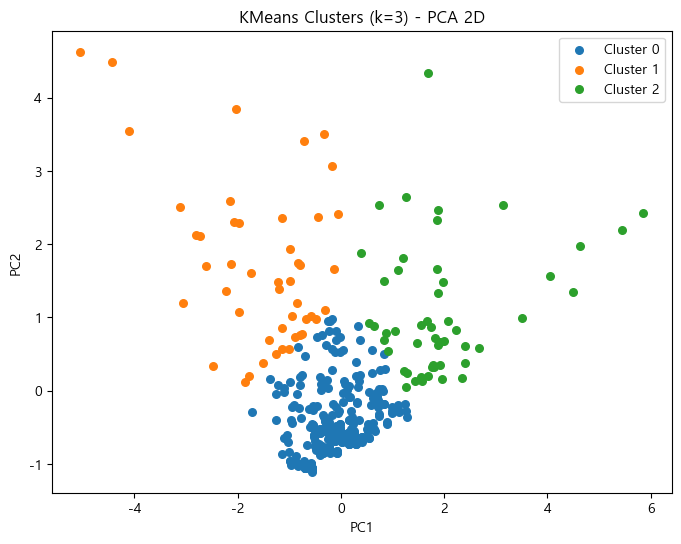

In [48]:
# 1) best_K 정하기
best_k = 3

# 2) best_k로 KMeans 학습
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

# 3) PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

# 4) 시각화
plt.figure(figsize=(8, 6))

for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - PCA 2D")
plt.legend()
plt.show()

In [49]:
# 평가
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch = calinski_harabasz_score(X_final, labels)

print("Kmeans results")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results
n_cluster = 3
Silhouette =  0.5071
DBI        =  1.0389
CH Index   =  183.0844


In [50]:
# Kmeans results
# n_cluster = 4
# Silhouette =  0.4831
# DBI        =  0.9447
# CH Index   =  183.9429

# Kmeans results
# n_cluster = 5
# Silhouette =  0.2912
# DBI        =  0.9787
# CH Index   =  193.5507

In [51]:
df_yoy_input["cluster"] = labels

profile = (df_yoy_input.groupby("cluster")
                       .agg(n=("new_corp_yoy", "size"),
                            # 증가율
                            yoy_mean=("new_corp_yoy", "mean"),
                            qoq_mean=("new_corp_qoq", "mean"),
                            # 절대 수준 — scale 차이를 해석에 반영
                            cnt_mean=("new_corp_cnt", "mean"),
                            cnt_roll4=("cnt_roll4_mean", "mean"),
                            cnt_diff4_mean=("cnt_diff4", "mean"),
                            # 품질 점검
                            yoy_miss=("yoy_missing", "mean"),
                            qoq_miss=("qoq_missing", "mean"))
                       .round(2))
print(profile)



           n  yoy_mean  qoq_mean  cnt_mean  cnt_roll4  cnt_diff4_mean  \
cluster                                                                 
0        302     -9.90    -17.47      3.14       3.40           -0.43   
1         47    -29.58    -16.14     20.43      23.28           -8.43   
2         51     99.83    159.69     17.08      13.48            6.80   

         yoy_miss  qoq_miss  
cluster                      
0            0.22      0.08  
1            0.00      0.00  
2            0.06      0.00  


cluster[0]: 작은 규모(평균 신규기업 수 3.14) + 정체(0.43) <br>
cluster[1]: 큰 규모(평균 신규기업 수 23.28) + 1년 전에 비해 신규기업 감소(-8.43) <br>
cluster[2]: 큰/중간 규모(평균 신규기업 수 17.08) + 1년 전에 비해 신규기업 증가(6.80) <br>

### (2) 외부유입 인구

1. 증가율

In [52]:
df_in = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
            "base_quarter", "external_inflow"]].copy()

df_in = df_in.sort_values(["adm_dong_cd", "year", "quarter"]).reset_index(drop=True)

# external_inflow 자체 규모 반영: log 변환
df_in["external_inflow_log"] = np.log1p(df_in["external_inflow"].clip(lower=0))

# YoY: 전년 동분기 대비
df_in["inflow_prev"] = (
    df_in.groupby(["adm_dong_cd", "quarter"])["external_inflow"].shift(1)
)

df_in["inflow_yoy"] = (
    (df_in["external_inflow"] - df_in["inflow_prev"]) / df_in["inflow_prev"]
  ) * 100

# QoQ: 직전 분기 대비
df_in["inflow_qoq"] = (
      df_in.groupby("adm_dong_cd")["external_inflow"].pct_change() * 100
)

# 최근 4분기 평균
df_in["inflow_recent4_mean"] = (
    df_in.groupby("adm_dong_cd")["external_inflow"]
        .transform(lambda s: s.rolling(4, min_periods=1).mean())
)

df_in["inflow_recent4_mean_log"] = np.log1p(
    df_in["inflow_recent4_mean"].clip(lower=0)
)

# 최근 4분기 slope
def rolling_slope(values):
    x = np.arange(len(values))
    return np.polyfit(x, values, 1)[0] if len(values) > 1 else np.nan

df_in["inflow_slope_4q"] = (
    df_in.groupby("adm_dong_cd")["external_inflow"]
        .transform(lambda s: s.rolling(4, min_periods=2)
                                .apply(lambda y: rolling_slope(y.values), raw=False))
)

2. 전처리

In [53]:
# missing flag는 군집 feature가 아니라 품질 점검용으로만 사용
df_in["yoy_missing"] = (
    df_in["inflow_prev"].isna() | (df_in["inflow_prev"] == 0)
).astype(int)

df_in["qoq_missing"] = df_in["inflow_qoq"].isna().astype(int)
df_in["slope_missing"] = df_in["inflow_slope_4q"].isna().astype(int)

value_cols = ["inflow_yoy", "inflow_qoq", "inflow_slope_4q"]
df_in[value_cols] = (
    df_in[value_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

quality_check = (
    df_in.groupby("year")[["yoy_missing", "qoq_missing", "slope_missing"]]
        .mean()
        .rename(columns=lambda c: f"{c}_ratio")
        .round(3)
)

display(quality_check)

,yoy_missing_ratio,qoq_missing_ratio,slope_missing_ratio
year,,,
2023,1.0,0.25,0.25
2024,0.0,0.00,0.00
2025,0.0,0.00,0.00


3. 클러스터링

In [54]:
# YoY 기반 분석에서는 전년 동분기 값이 없는 2023년을 K-Means 입력에서 제외
df_in_model = df_in[df_in["year"] != 2023].copy()

scenario_features = {
    "YoY + log inflow": [
        "external_inflow_log",
        "inflow_yoy"
    ],
    "YoY + QoQ + log inflow": [
        "external_inflow_log",
        "inflow_yoy",
        "inflow_qoq"
    ],
    "Recent trend": [
        "external_inflow_log",
        "inflow_qoq",
        "inflow_recent4_mean_log",
        "inflow_slope_4q"
    ],
    "Combined": [
        "external_inflow_log",
        "inflow_yoy",
        "inflow_qoq",
        "inflow_recent4_mean_log",
        "inflow_slope_4q"
    ],
}

k_values = range(2, 11)
scenario_rows = []

for scenario, features in scenario_features.items():
    X = StandardScaler().fit_transform(df_in_model[features])

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels_tmp = model.fit_predict(X)

        scenario_rows.append({
            "scenario": scenario,
            "features": ", ".join(features),
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels_tmp),
            "dbi": davies_bouldin_score(X, labels_tmp),
            "ch": calinski_harabasz_score(X, labels_tmp),
        })

scenario_results = pd.DataFrame(scenario_rows)

scenario_summary = (
    scenario_results
    .sort_values(["silhouette", "dbi"], ascending=[False, True])
    .groupby("scenario", as_index=False)
    .head(1)
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)

display(
    scenario_summary[
        ["scenario", "k", "silhouette", "dbi", "ch", "features"]
    ].round(4)
)

,scenario,k,silhouette,dbi,ch,features
0,YoY + log inflow,3,0.4474,0.7994,281.0178,"external_inflow_log, inflow_yoy"
1,Recent trend,4,0.3681,0.8996,229.6846,"external_inflow_log, inflow_qoq, inflow_recent..."
2,YoY + QoQ + log inflow,4,0.3621,0.9859,180.4713,"external_inflow_log, inflow_yoy, inflow_qoq"
3,Combined,5,0.3248,1.0798,164.2614,"external_inflow_log, inflow_yoy, inflow_qoq, i..."


In [55]:
selected_scenario = scenario_summary.loc[0, "scenario"]
selected_features = scenario_features[selected_scenario]
best_k = int(scenario_summary.loc[0, "k"])

scaler = StandardScaler()
X_final = scaler.fit_transform(df_in_model[selected_features])

Explained variance ratio: [0.5728993 0.4271007]
총 설명 분산: 0.9999999999999999


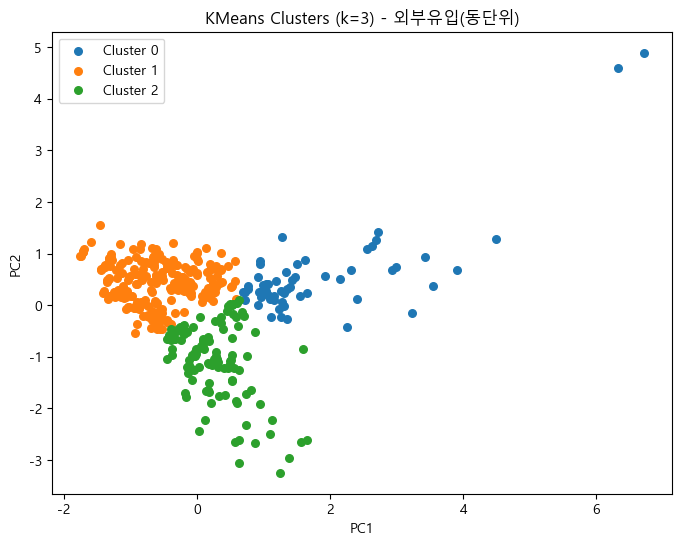

In [56]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - 외부유입(동단위)")
plt.legend()
plt.show()

In [57]:
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch  = calinski_harabasz_score(X_final, labels)

print("Kmeans results - 외부유입 인구 증가율")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results - 외부유입 인구 증가율
n_cluster = 3
Silhouette =  0.4474
DBI        =  0.7994
CH Index   =  281.0178


In [58]:
df_in_model["cluster"] = labels

profile_in = (
    df_in_model.groupby("cluster")
                .agg(
                    n=("external_inflow", "size"),
                    external_inflow_mean=("external_inflow", "mean"),
                    external_inflow_median=("external_inflow", "median"),
                    inflow_yoy_mean=("inflow_yoy", "mean"),
                    inflow_qoq_mean=("inflow_qoq", "mean"),
                    recent4_mean=("inflow_recent4_mean", "mean"),
                    slope_4q_mean=("inflow_slope_4q", "mean"),
                    yoy_miss_ratio=("yoy_missing", "mean"),
                    qoq_miss_ratio=("qoq_missing", "mean"),
                    slope_miss_ratio=("slope_missing", "mean"),
                )
                .round(2)
)

display(profile_in)

print(df_in_model.groupby(["cluster", "year"]).size().unstack(fill_value=0))

,n,external_inflow_mean,external_inflow_median,inflow_yoy_mean,inflow_qoq_mean,recent4_mean,slope_4q_mean,yoy_miss_ratio,qoq_miss_ratio,slope_miss_ratio
cluster,,,,,,,,,,
0,57,272010.03,273874.54,77.36,14.68,232909.69,28092.55,0.0,0.0,0.0
1,225,1500058.06,1174330.56,12.75,2.84,1450519.45,34027.98,0.0,0.0,0.0
2,118,277014.74,279504.20,-3.03,1.60,277083.89,-1500.50,0.0,0.0,0.0


year     2024  2025
cluster            
0           0    57
1         100   125
2         100    18


df_in_model["cluster"] = labels

profile_in = (
    df_in_model.groupby("cluster")
                .agg(
                    n=("external_inflow", "size"),
                    external_inflow_mean=("external_inflow", "mean"),
                    external_inflow_median=("external_inflow", "median"),
                    inflow_yoy_mean=("inflow_yoy", "mean"),
                    inflow_qoq_mean=("inflow_qoq", "mean"),
                    recent4_mean=("inflow_recent4_mean", "mean"),
                    slope_4q_mean=("inflow_slope_4q", "mean"),
                    yoy_miss_ratio=("yoy_missing", "mean"),
                    qoq_miss_ratio=("qoq_missing", "mean"),
                    slope_miss_ratio=("slope_missing", "mean"),
                )
                .round(2)
)

display(profile_in)

print(df_in_model.groupby(["cluster", "year"]).size().unstack(fill_value=0))

(3) 상권활력도

In [59]:
# 1. 전체 개폐업 점포 수
total_open_sum  = df['open_cnt'].sum()
total_close_sum = df['close_cnt'].sum()

# 2. 동별(prefix) 개업 점포 수의 합계
df_open  = df.groupby(['adm_dong_cd', 'adm_dong_nm', 'base_quarter'])['open_cnt'].sum().reset_index()
df_close = df.groupby(['adm_dong_cd', 'adm_dong_nm', 'base_quarter'])['close_cnt'].sum().reset_index()

# 3. 비중(Ratio)을 계산 (동별 합계 / 전체 합계)
df_open['open_ratio']   = (df_open['open_cnt']   / total_open_sum)  * 100
df_close['close_ratio'] = (df_close['close_cnt'] / total_close_sum) * 100

df_pct = df_open.merge(df_close, on=['adm_dong_cd', 'adm_dong_nm', 'base_quarter'], how='inner')
df_pct['mkt_vital'] = df_pct['open_ratio'] - df_pct['close_ratio']

In [60]:
def trend_slope(s):
    x = np.arange(len(s))
    return np.polyfit(x, s.values, 1)[0] if len(s) > 1 else 0

agg_mkt = (
    df_pct.sort_values("base_quarter")
          .groupby(["adm_dong_cd", "adm_dong_nm"])["mkt_vital"]
          .agg(mean="mean", std="std", median="median",
               p90=lambda s: s.quantile(0.9),
               slope=trend_slope)
          .reset_index()
          .fillna(0)
)

features = ["mean", "std", "median", "p90", "slope"]
X_final = StandardScaler().fit_transform(agg_mkt[features])

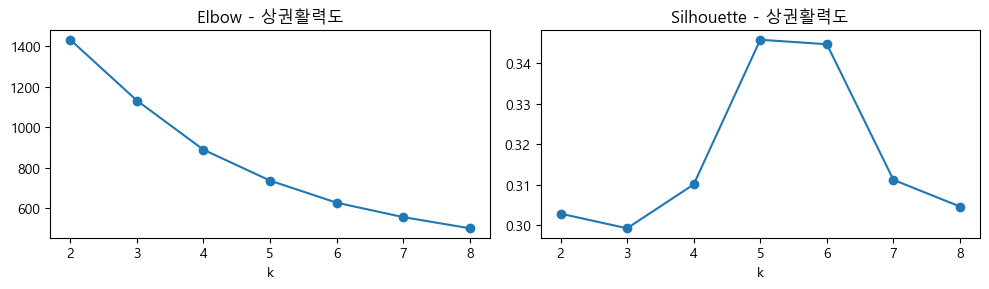

In [61]:
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Elbow - 상권활력도"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sils, "o-");     ax[1].set_title("Silhouette - 상권활력도"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

In [62]:
k = 4
agg_mkt["cluster"] = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

sil = silhouette_score(X, agg_mkt["cluster"])
dbi = davies_bouldin_score(X, agg_mkt["cluster"])
ch  = calinski_harabasz_score(X, agg_mkt["cluster"])
print("Kmeans results - 상권활력도(동단위)")
print(f"n_cluster = {k}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

ValueError: Length of values (400) does not match length of index (50)

In [ ]:
# Kmeans results - 상권활력도(동단위)
# n_cluster = 3
# Silhouette =  0.4718
# DBI        =  0.7105
# CH Index   =  51.8725

In [ ]:
profile = agg_mkt.groupby("cluster")[features].mean().round(2)
print(profile)

In [ ]:
coords = PCA(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1],
                hue=agg_mkt["cluster"], palette="viridis", s=80)

for i, name in enumerate(agg_mkt["adm_dong_nm"]):
    plt.annotate(name, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.7)

plt.title("동 단위 mkt_vital 군집")
plt.tight_layout(); plt.show()

(4) 프랜차이즈

1. 증가율 계산

In [64]:
df_fc = df[[
    "adm_dong_cd", "adm_dong_nm", "year", "quarter",
    "base_quarter", "franchise_cnt"
]].copy()

df_fc = df_fc.sort_values(["adm_dong_cd", "year", "quarter"])

# franchise_ratio가 원본에 있으면 사용, 없으면 분기 전체 대비 비중으로 계산
if "franchise_ratio" in df.columns:
    df_fc["franchise_ratio"] = df["franchise_ratio"]
else:
    quarter_total = df_fc.groupby("base_quarter")["franchise_cnt"].transform("sum")
    df_fc["franchise_ratio"] = df_fc["franchise_cnt"] / quarter_total * 100

# YoY: 전년 동분기 대비
df_fc["franchise_cnt_prev_yoy"] = (
    df_fc.groupby(["adm_dong_cd", "quarter"])["franchise_cnt"].shift(1)
)

df_fc["franchise_ratio_prev_yoy"] = (
    df_fc.groupby(["adm_dong_cd", "quarter"])["franchise_ratio"].shift(1)
)

df_fc["franchise_yoy"] = (
    (df_fc["franchise_cnt"] - df_fc["franchise_cnt_prev_yoy"])
    / df_fc["franchise_cnt_prev_yoy"]
) * 100

df_fc["franchise_ratio_diff_yoy"] = (
    df_fc["franchise_ratio"] - df_fc["franchise_ratio_prev_yoy"]
)

# QoQ: 직전 분기 대비
df_fc["franchise_qoq"] = (
    df_fc.groupby("adm_dong_cd")["franchise_cnt"].pct_change() * 100
)

df_fc["franchise_ratio_diff_qoq"] = (
    df_fc.groupby("adm_dong_cd")["franchise_ratio"].diff()
)

# 최근 4분기 평균 및 slope
def rolling_slope(values):
    values = pd.Series(values).dropna()
    if len(values) < 2:
        return np.nan
    x = np.arange(len(values))
    return np.polyfit(x, values, 1)[0]

df_fc["franchise_recent4_mean"] = (
    df_fc.groupby("adm_dong_cd")["franchise_cnt"]
        .transform(lambda s: s.rolling(4, min_periods=2).mean())
)

df_fc["franchise_ratio_recent4_mean"] = (
    df_fc.groupby("adm_dong_cd")["franchise_ratio"]
        .transform(lambda s: s.rolling(4, min_periods=2).mean())
)

df_fc["franchise_slope_4q"] = (
    df_fc.groupby("adm_dong_cd")["franchise_cnt"]
        .transform(lambda s: s.rolling(4, min_periods=2).apply(rolling_slope, raw=False))
)

df_fc["franchise_ratio_slope_4q"] = (
    df_fc.groupby("adm_dong_cd")["franchise_ratio"]
        .transform(lambda s: s.rolling(4, min_periods=2).apply(rolling_slope, raw=False))
)

# missing flag는 군집 feature가 아니라 품질 점검 변수로만 사용
df_fc["yoy_missing"] = (
    df_fc["franchise_cnt_prev_yoy"].isna()
    | (df_fc["franchise_cnt_prev_yoy"] == 0)
).astype(int)

df_fc["qoq_missing"] = df_fc["franchise_qoq"].isna().astype(int)
df_fc["slope_missing"] = df_fc["franchise_slope_4q"].isna().astype(int)

quality_check_fc = (
    df_fc.groupby("year")[["yoy_missing", "qoq_missing", "slope_missing"]]
        .mean()
        .rename(columns=lambda c: f"{c}_ratio")
        .round(3)
)

display(quality_check_fc)

value_cols = [
    "franchise_yoy",
    "franchise_qoq",
    "franchise_ratio",
    "franchise_ratio_diff_yoy",
    "franchise_ratio_diff_qoq",
    "franchise_recent4_mean",
    "franchise_ratio_recent4_mean",
    "franchise_slope_4q",
    "franchise_ratio_slope_4q",
]

df_fc[value_cols] = (
    df_fc[value_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# YoY 기반 분석에서는 2023년 제외
# 동 단위 집계 없이 분기-동 단위 관측치 그대로 사용
df_fc_model = df_fc[df_fc["year"] != 2023].copy()

scenario_features = {
    "YoY 중심": [
        "franchise_yoy",
        "franchise_ratio",
        "franchise_ratio_diff_yoy",
    ],
    "QoQ 단기 변화": [
        "franchise_qoq",
        "franchise_ratio",
        "franchise_ratio_diff_qoq",
    ],
    "최근 4분기 추세": [
        "franchise_recent4_mean",
        "franchise_ratio_recent4_mean",
        "franchise_slope_4q",
        "franchise_ratio_slope_4q",
    ],
    "단기 변화 + 최근 추세": [
        "franchise_qoq",
        "franchise_ratio",
        "franchise_ratio_diff_qoq",
        "franchise_ratio_recent4_mean",
        "franchise_ratio_slope_4q",
    ],
}

k_values = range(2, 11)
scenario_rows = []

for scenario, feats in scenario_features.items():
    X = StandardScaler().fit_transform(df_fc_model[feats])

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels_tmp = model.fit_predict(X)

        scenario_rows.append({
            "scenario": scenario,
            "features": ", ".join(feats),
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels_tmp),
            "dbi": davies_bouldin_score(X, labels_tmp),
            "ch": calinski_harabasz_score(X, labels_tmp),
        })

scenario_results_fc = pd.DataFrame(scenario_rows)

scenario_summary_fc = (
    scenario_results_fc
    .sort_values(["silhouette", "dbi"], ascending=[False, True])
    .groupby("scenario", as_index=False)
    .head(1)
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)

display(
    scenario_summary_fc[
        ["scenario", "k", "silhouette", "dbi", "ch", "features"]
    ].round(4)
)

,yoy_missing_ratio,qoq_missing_ratio,slope_missing_ratio
year,,,
2023,1.0,0.25,0.25
2024,0.0,0.00,0.00
2025,0.0,0.00,0.00


,scenario,k,silhouette,dbi,ch,features
0,최근 4분기 추세,2,0.6938,0.8752,275.9319,"franchise_recent4_mean, franchise_ratio_recent..."
1,YoY 중심,2,0.3975,1.1983,177.4440,"franchise_yoy, franchise_ratio, franchise_rati..."
2,단기 변화 + 최근 추세,2,0.3913,1.4662,123.6259,"franchise_qoq, franchise_ratio, franchise_rati..."
3,QoQ 단기 변화,2,0.3311,1.2700,148.7766,"franchise_qoq, franchise_ratio, franchise_rati..."


3. 클러스터링

In [65]:
selected = scenario_summary_fc.iloc[0]
selected_scenario = selected["scenario"]
best_k = int(selected["k"])

features = scenario_features[selected_scenario]
X_final = StandardScaler().fit_transform(df_fc_model[features])

Explained variance ratio: [0.54896465 0.34326018]
총 설명 분산: 0.8922248242173911


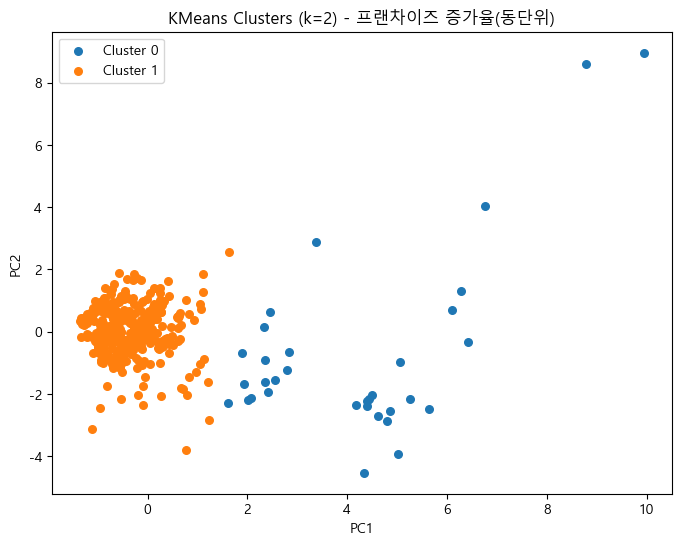

In [66]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - 프랜차이즈 증가율(동단위)")
plt.legend()
plt.show()

In [67]:
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch  = calinski_harabasz_score(X_final, labels)

print("Kmeans results - 프랜차이즈 증가율(동단위)")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results - 프랜차이즈 증가율(동단위)
n_cluster = 2
Silhouette =  0.6938
DBI        =  0.8752
CH Index   =  275.9319


In [68]:
df_fc_model["cluster"] = labels
profile_fc = (
    df_fc_model.groupby("cluster")
    .agg(
        n=("adm_dong_cd", "size"),
        franchise_cnt_mean=("franchise_cnt", "mean"),
        franchise_ratio_mean=("franchise_ratio", "mean"),
        franchise_yoy_mean=("franchise_yoy", "mean"),
        franchise_qoq_mean=("franchise_qoq", "mean"),
        ratio_diff_yoy_mean=("franchise_ratio_diff_yoy", "mean"),
        ratio_diff_qoq_mean=("franchise_ratio_diff_qoq", "mean"),
        ratio_recent4_mean=("franchise_ratio_recent4_mean", "mean"),
        ratio_slope_4q_mean=("franchise_ratio_slope_4q", "mean"),
        yoy_missing_ratio=("yoy_missing", "mean"),
        qoq_missing_ratio=("qoq_missing", "mean"),
        slope_missing_ratio=("slope_missing", "mean"),
    )
    .round(2)
)

display(profile_fc)

display(
    df_fc_model[[
        "adm_dong_nm", "year", "quarter", "base_quarter",
        "franchise_cnt", "franchise_ratio",
        "franchise_yoy", "franchise_qoq",
        "franchise_ratio_diff_qoq",
        "franchise_ratio_slope_4q",
        "cluster"
    ]].sort_values(["cluster", "adm_dong_nm", "year", "quarter"])
)

,n,franchise_cnt_mean,franchise_ratio_mean,franchise_yoy_mean,franchise_qoq_mean,ratio_diff_yoy_mean,ratio_diff_qoq_mean,ratio_recent4_mean,ratio_slope_4q_mean,yoy_missing_ratio,qoq_missing_ratio,slope_missing_ratio
cluster,,,,,,,,,,,,
0,33,2128.58,12.35,17.87,3.66,0.43,0.03,12.23,0.10,0.0,0.0,0.0
1,367,313.56,5.62,2.18,-0.02,-0.12,-0.07,5.70,-0.04,0.0,0.0,0.0


,adm_dong_nm,year,quarter,base_quarter,franchise_cnt,franchise_ratio,franchise_yoy,franchise_qoq,franchise_ratio_diff_qoq,franchise_ratio_slope_4q,cluster
544,백현동,2024,1,2024Q1,2255.0,18.465444,22.955289,7.688634,0.478844,0.369170,0
545,백현동,2024,2,2024Q2,2301.0,16.879401,18.060544,2.039911,-1.586042,-0.216128,0
546,백현동,2024,3,2024Q3,2368.0,16.501742,15.794621,2.911777,-0.377659,-0.604062,0
547,백현동,2024,4,2024Q4,2415.0,16.409594,15.329513,1.984797,-0.092148,-0.654521,0
548,백현동,2025,1,2025Q1,2449.0,16.313616,8.603104,1.407867,-0.095979,-0.178950,0
...,...,...,...,...,...,...,...,...,...,...,...
319,하대원동,2024,4,2024Q4,155.0,3.021442,3.333333,2.649007,0.088834,0.024813,1
320,하대원동,2025,1,2025Q1,157.0,2.912261,7.534247,1.290323,-0.109181,0.025940,1
321,하대원동,2025,2,2025Q2,151.0,2.798369,7.092199,-3.821656,-0.113892,-0.051190,1
322,하대원동,2025,3,2025Q3,159.0,2.831197,5.298013,5.298013,0.032827,-0.068463,1


### (5) 젠트리피케이션 위험 군집 — 신규기업·프랜차이즈·외부유입 증가율 + 상권활력도

1. 증가율 계산

In [ ]:
# 신규기업 증가율
df_new = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
             "base_quarter", "new_corp_cnt"]].copy()
df_new = df_new.sort_values(["adm_dong_cd", "year", "quarter"])

df_new["new_corp_prev"] = (
    df_new.groupby(["adm_dong_cd", "quarter"])["new_corp_cnt"].shift(1)
)
df_new["new_corp_yoy"] = (
    (df_new["new_corp_cnt"] - df_new["new_corp_prev"]) / df_new["new_corp_prev"]
) * 100

# 프랜차이즈 증가율
df_fr = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
            "base_quarter", "franchise_cnt"]].copy()
df_fr = df_fr.sort_values(["adm_dong_cd", "year", "quarter"])

df_fr["franchise_prev"] = (
    df_fr.groupby(["adm_dong_cd", "quarter"])["franchise_cnt"].shift(1)
)
df_fr["franchise_yoy"] = (
    (df_fr["franchise_cnt"] - df_fr["franchise_prev"]) / df_fr["franchise_prev"]
) * 100

# 외부유입 인구 증가율
df_inf = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
             "base_quarter", "external_inflow"]].copy()
df_inf = df_inf.sort_values(["adm_dong_cd", "year", "quarter"])

df_inf["inflow_prev"] = (
    df_inf.groupby(["adm_dong_cd", "quarter"])["external_inflow"].shift(1)
)
df_inf["inflow_yoy"] = (
    (df_inf["external_inflow"] - df_inf["inflow_prev"]) / df_inf["inflow_prev"]
) * 100

In [ ]:
# 상권 활력도
total_open  = df["open_cnt"].sum()
total_close = df["close_cnt"].sum()

df_mkt = (df.groupby(["adm_dong_cd", "adm_dong_nm", "base_quarter"])
            .agg(open_cnt=("open_cnt", "sum"),
                 close_cnt=("close_cnt", "sum"))
            .reset_index())

df_mkt["open_ratio"]  = df_mkt["open_cnt"]  / total_open  * 100
df_mkt["close_ratio"] = df_mkt["close_cnt"] / total_close * 100
df_mkt["mkt_vital"]   = df_mkt["open_ratio"] - df_mkt["close_ratio"]


2. 전처리

In [ ]:
# 신규기업
df_new["new_corp_missing"] = (
    df_new["new_corp_prev"].isna() | (df_new["new_corp_prev"] == 0)
).astype(int)
df_new["new_corp_yoy"] = (df_new["new_corp_yoy"]
                            .replace([np.inf, -np.inf], np.nan).fillna(0))

# 프랜차이즈
df_fr["franchise_missing"] = (
    df_fr["franchise_prev"].isna() | (df_fr["franchise_prev"] == 0)
).astype(int)
df_fr["franchise_yoy"] = (df_fr["franchise_yoy"]
                            .replace([np.inf, -np.inf], np.nan).fillna(0))

# 외부유입
df_inf["inflow_missing"] = (
    df_inf["inflow_prev"].isna() | (df_inf["inflow_prev"] == 0)
).astype(int)
df_inf["inflow_yoy"] = (df_inf["inflow_yoy"]
                          .replace([np.inf, -np.inf], np.nan).fillna(0))


3. 통합 데이터프레임

In [ ]:
df_gent = (
    df_new[["adm_dong_cd", "adm_dong_nm", "base_quarter",
            "new_corp_yoy", "new_corp_missing"]]
    .merge(df_fr[["adm_dong_cd", "base_quarter",
                  "franchise_yoy", "franchise_missing"]],
           on=["adm_dong_cd", "base_quarter"], how="inner")
    .merge(df_inf[["adm_dong_cd", "base_quarter",
                   "inflow_yoy", "inflow_missing"]],
           on=["adm_dong_cd", "base_quarter"], how="inner")
    .merge(df_mkt[["adm_dong_cd", "base_quarter", "mkt_vital"]],
           on=["adm_dong_cd", "base_quarter"], how="inner")
)

print(df_gent.shape)
df_gent.head()


4. EDA

In [ ]:
fig = px.scatter_matrix(
    df_gent,
    dimensions=["new_corp_yoy", "franchise_yoy", "inflow_yoy", "mkt_vital"],
    title="상권 데이터 탐색 (Scatter Matrix)"
)
fig.update_traces(diagonal_visible=False)

fig.update_yaxes(
    tickangle=45,
    automargin=True
)

fig.update_layout(
    height=700,
    margin=dict(l=120, r=40, t=80, b=80)
)
fig.show()

cols = ["new_corp_yoy", "franchise_yoy", "inflow_yoy", "mkt_vital"]
corr = df_gent[cols].corr().round(2)
fig_corr = px.imshow(
    corr, text_auto=True, color_continuous_scale="RdBu_r",
    title="상관계수 히트맵"
)
fig_corr.update_layout(width=600, height=500)
fig_corr.show()

4. 클러스터링

In [ ]:
num_features = ["new_corp_yoy", "franchise_yoy", "inflow_yoy", "mkt_vital"]
cat_features = ["new_corp_missing", "franchise_missing", "inflow_missing"]

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(df_gent[num_features])

X_final = np.hstack([X_scaled_num, df_gent[cat_features].values])


In [ ]:
import plotly.graph_objects as go

In [ ]:
wcss, sil = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_final)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_final, labels))

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(K_range), y=wcss, mode="lines+markers", name="WCSS (Elbow)"))
fig.add_trace(go.Scatter(x=list(K_range), y=sil, mode="lines+markers", name="Silhouette"))
fig.update_layout(
    title="K 후보 비교 — Elbow(WCSS) vs Silhouette",
    xaxis_title="K(군집 수)", yaxis_title="Score / WCSS"
)
fig.show()

best_k = list(K_range)[int(np.argmax(sil))]
print(f"Silhouette 최고점 기준 추천 K = {best_k}")

In [ ]:
k = int(best_k)
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)
df_gent["Cluster"] = labels

sil_score = silhouette_score(X_final, labels)
sizes = pd.Series(labels, name="Cluster").value_counts().sort_index()

print(f"전체 Silhouette Score: {sil_score:.3f}")

centers_scaled = kmeans.cluster_centers_ 
num_part = scaler.inverse_transform(centers_scaled[:, :len(num_features)])
cat_part = centers_scaled[:, len(num_features):]
centers = pd.DataFrame(
    np.hstack([num_part, cat_part]),
    columns=num_features + cat_features
).round(2)

centers.index.name = "Cluster"
print("동 단위 클러스터 중심:")
display(centers)

In [ ]:
fig_3d = px.scatter_3d(
    df_gent, x="new_corp_yoy", y="franchise_yoy", z="inflow_yoy",
    color=df["Cluster"].astype(str),
    title="고객 세분화 (3D) — new_corp_yoy / franchise_yoy / inflow_yoy",
    symbol=df["Cluster"].astype(str)
)
fig_3d.update_traces(marker=dict(size=5, opacity=0.85))
fig_3d.show()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = df_gent["Cluster"]

expl = pca.explained_variance_ratio_
fig_pca = px.scatter(
    df_pca, x="PC1", y="PC2", color=df["Cluster"].astype(str),
    title=f"PCA 2D 투영 (설명력: PC1 {expl[0]*100:.1f}%, PC2 {expl[1]*100:.1f}%)"
)
fig_pca.update_traces(marker=dict(size=8, opacity=0.9))
fig_pca.show()

In [ ]:
k_values = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X_final)
    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X_final, labels))

plt.figure()
plt.plot(k_values, inertia_list)
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (K-Means) - 젠트리피케이션 위험")
plt.show()

plt.figure()
plt.plot(k_values, silhouette_list)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k - 젠트리피케이션 위험")
plt.show()


In [ ]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_num)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - 젠트리피케이션 위험")
plt.legend()
plt.show()


In [ ]:
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch  = calinski_harabasz_score(X_final, labels)

print("Kmeans results - 젠트리피케이션 위험")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

In [ ]:
# Kmeans results - 젠트리피케이션 위험
# n_cluster = 4
# Silhouette =  0.2984
# DBI        =  1.2907
# CH Index   =  137.6589

# Kmeans results - 젠트리피케이션 위험
# n_cluster = 5
# Silhouette =  0.3161
# DBI        =  1.2295
# CH Index   =  150.0596

# Kmeans results - 젠트리피케이션 위험
# n_cluster = 6
# Silhouette =  0.3319
# DBI        =  1.1049
# CH Index   =  151.2611

In [ ]:
df_gent["cluster"] = labels

profile = (df_gent.groupby("cluster")
                  .agg(n=("new_corp_yoy", "size"),
                       new_corp_yoy=("new_corp_yoy", "mean"),
                       franchise_yoy=("franchise_yoy", "mean"),
                       inflow_yoy=("inflow_yoy", "mean"),
                       mkt_vital=("mkt_vital", "mean"),
                       new_corp_miss=("new_corp_missing", "mean"),
                       franchise_miss=("franchise_missing", "mean"),
                       inflow_miss=("inflow_missing", "mean"))
                  .round(2))
print(profile)
print()

# cluster별 분기 분포
print(df_gent.groupby(["cluster", "base_quarter"]).size().unstack(fill_value=0))

In [ ]:
summary = df_gent.groupby("Cluster")[["new_corp_yoy","franchise_yoy","inflow_yoy"]].agg(["mean","std","median"]).round(2)
display(summary)

summary_mean = df_gent.groupby("Cluster")[["new_corp_yoy","franchise_yoy","inflow_yoy"]].mean().round(2).reset_index()
sm = summary_mean.melt(id_vars="Cluster", var_name="Feature", value_name="Mean")

fig_bar = px.bar(
    sm, x="Feature", y="Mean", color="Cluster", barmode="group",
    title="클러스터별 평균 Feature 비교"
)
fig_bar.show()

for col in ["new_corp_yoy","franchise_yoy","inflow_yoy"]:
    fig_box = px.box(df_gent, x="Cluster", y=col, title=f"{col} 분포 (클러스터별)")
    fig_box.show()